###  Analisis exploratorio de datos
Este es el Notebook de Exploración del Dataset

dataset: Chicago_crimes_2021_2017

Librerias usada:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler

%matplotlib inline

In [ ]:
# Cargamos el dataset
crimes = pd.read_csv('Chicago_Crimes_2012_to_2017.csv')

print('Dataset listo..')

print('Tamaño del Dataset antes de eliminar duplicados: ', crimes.shape)
crimes.drop_duplicates(subset=['ID', 'Case Number'], inplace=True)
print('Tamaño del Dataset después de eliminar duplicados: ', crimes.shape)


Dataset listo..
Tamaño del Dataset antes de eliminar duplicados:  (1456714, 23)
Tamaño del Dataset después de eliminar duplicados:  (1456714, 23)


## Preprocesamiento

**Eliminación de Atributos Irrelevantes para el análisis**

In [ ]:
crimes.drop(['Unnamed: 0', 'Case Number', 'IUCR','Updated On','Year', 'FBI Code', 'Beat','Ward','Community Area','Location'], inplace=True, axis=1)

In [ ]:
crimes.head(3)

,ID,Date,Block,Primary Type,Description,Location Description,Arrest,Domestic,District,X Coordinate,Y Coordinate,Latitude,Longitude
0,10508693,05/03/2016 11:40:00 PM,013XX S SAWYER AVE,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,True,True,10.0,1154907.0,1893681.0,41.864073,-87.706819
1,10508695,05/03/2016 09:40:00 PM,061XX S DREXEL AVE,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,3.0,1183066.0,1864330.0,41.782922,-87.604363
2,10508697,05/03/2016 11:31:00 PM,053XX W CHICAGO AVE,PUBLIC PEACE VIOLATION,RECKLESS CONDUCT,STREET,False,False,15.0,1140789.0,1904819.0,41.894908,-87.758372


**Conversión de Tipos**

Conversión de Tipo de la columna 'Date' a un formato de fecha para trabajar con python

In [ ]:
# Convertir las fechas al formato de fecha y hora de pandas.
crimes.Date = pd.to_datetime(crimes.Date, format='%m/%d/%Y %I:%M:%S %p')
# Establecer el índice como la fecha.
crimes.index = pd.DatetimeIndex(crimes.Date)

Se mantienen los 20 tipos de crímenes más comunes y se reemplazan los demás por la etiqeta 'Otro'

In [ ]:
loc_to_change  = list(crimes['Location Description'].value_counts()[20:].index)
desc_to_change = list(crimes['Description'].value_counts()[20:].index)
type_to_change = list(crimes['Primary Type'].value_counts()[20:].index)

crimes.loc[crimes['Location Description'].isin(loc_to_change) , crimes.columns=='Location Description'] = 'OTHER'
crimes.loc[crimes['Description'].isin(desc_to_change) , crimes.columns=='Description'] = 'OTHER'
crimes.loc[crimes['Primary Type'].isin(type_to_change) , crimes.columns=='Primary Type'] = 'OTHER'

In [ ]:
#Convertimos a tipos categoricos.
crimes['Primary Type']         = pd.Categorical(crimes['Primary Type'])
crimes['Location Description'] = pd.Categorical(crimes['Location Description'])
crimes['Description']          = pd.Categorical(crimes['Description'])

In [ ]:
# de registros y # de caracteristicas
crimes.shape

(1456714, 13)

In [ ]:
crimes.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1456714 entries, 2016-05-03 23:40:00 to 2016-05-03 23:38:00
Data columns (total 13 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   ID                    1456714 non-null  int64         
 1   Date                  1456714 non-null  datetime64[ns]
 2   Block                 1456714 non-null  object        
 3   Primary Type          1456714 non-null  category      
 4   Description           1456714 non-null  category      
 5   Location Description  1455056 non-null  category      
 6   Arrest                1456714 non-null  bool          
 7   Domestic              1456714 non-null  bool          
 8   District              1456713 non-null  float64       
 9   X Coordinate          1419631 non-null  float64       
 10  Y Coordinate          1419631 non-null  float64       
 11  Latitude              1419631 non-null  float64       
 12  Longitude

**Visualización de valores nulos**

<Axes: ylabel='Date'>

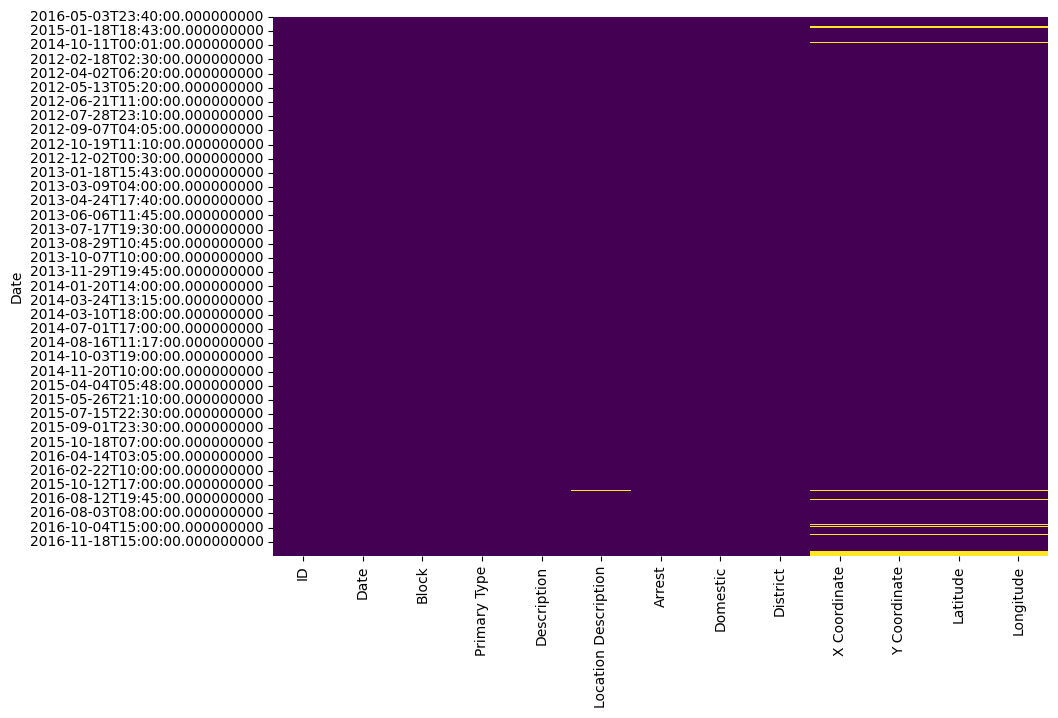

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(crimes.isnull(), cbar = False, cmap = 'viridis')

In [ ]:
crimes.dropna(inplace=True)

## Exploración y Visualización

<ipython-input-16-b4b4c96718d2>:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  crimes.resample('M').size().plot(legend=False)


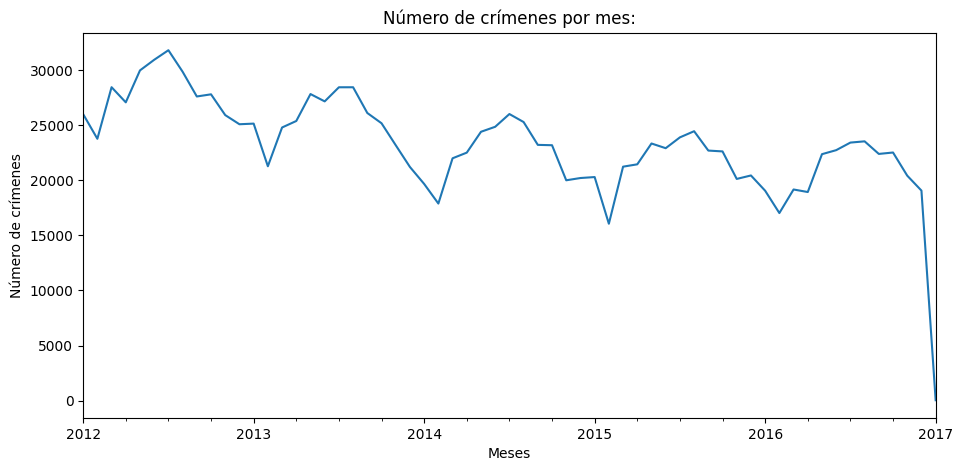

In [ ]:
plt.figure(figsize=(11,5))
crimes.resample('M').size().plot(legend=False)
plt.title('Número de crímenes por mes:')
plt.xlabel('Meses')
plt.ylabel('Número de crímenes')
plt.show()

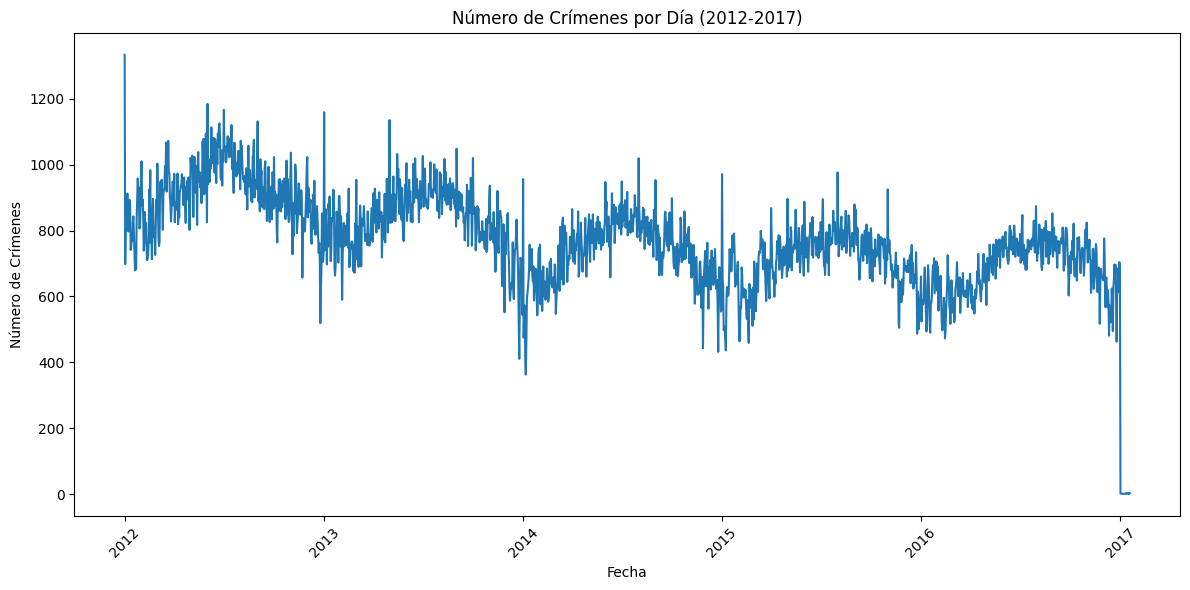

In [ ]:
crímenes_por_día = crimes.groupby(crimes.index.date).size()

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(crímenes_por_día.index, crímenes_por_día.values)
plt.xlabel("Fecha")
plt.ylabel("Número de Crímenes")
plt.title("Número de Crímenes por Día (2012-2017)")
plt.xticks(rotation=45)  # Rotar las etiquetas del eje x para mejor legibilidad
plt.tight_layout()  # Ajustar el diseño para evitar que las etiquetas se solapen
plt.show()

<ipython-input-18-5e1844d1c5ae>:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  crímenes_por_fecha = crimes.pivot_table('ID', aggfunc=np.size, columns='Primary Type', index=crimes.index.date, fill_value=0)


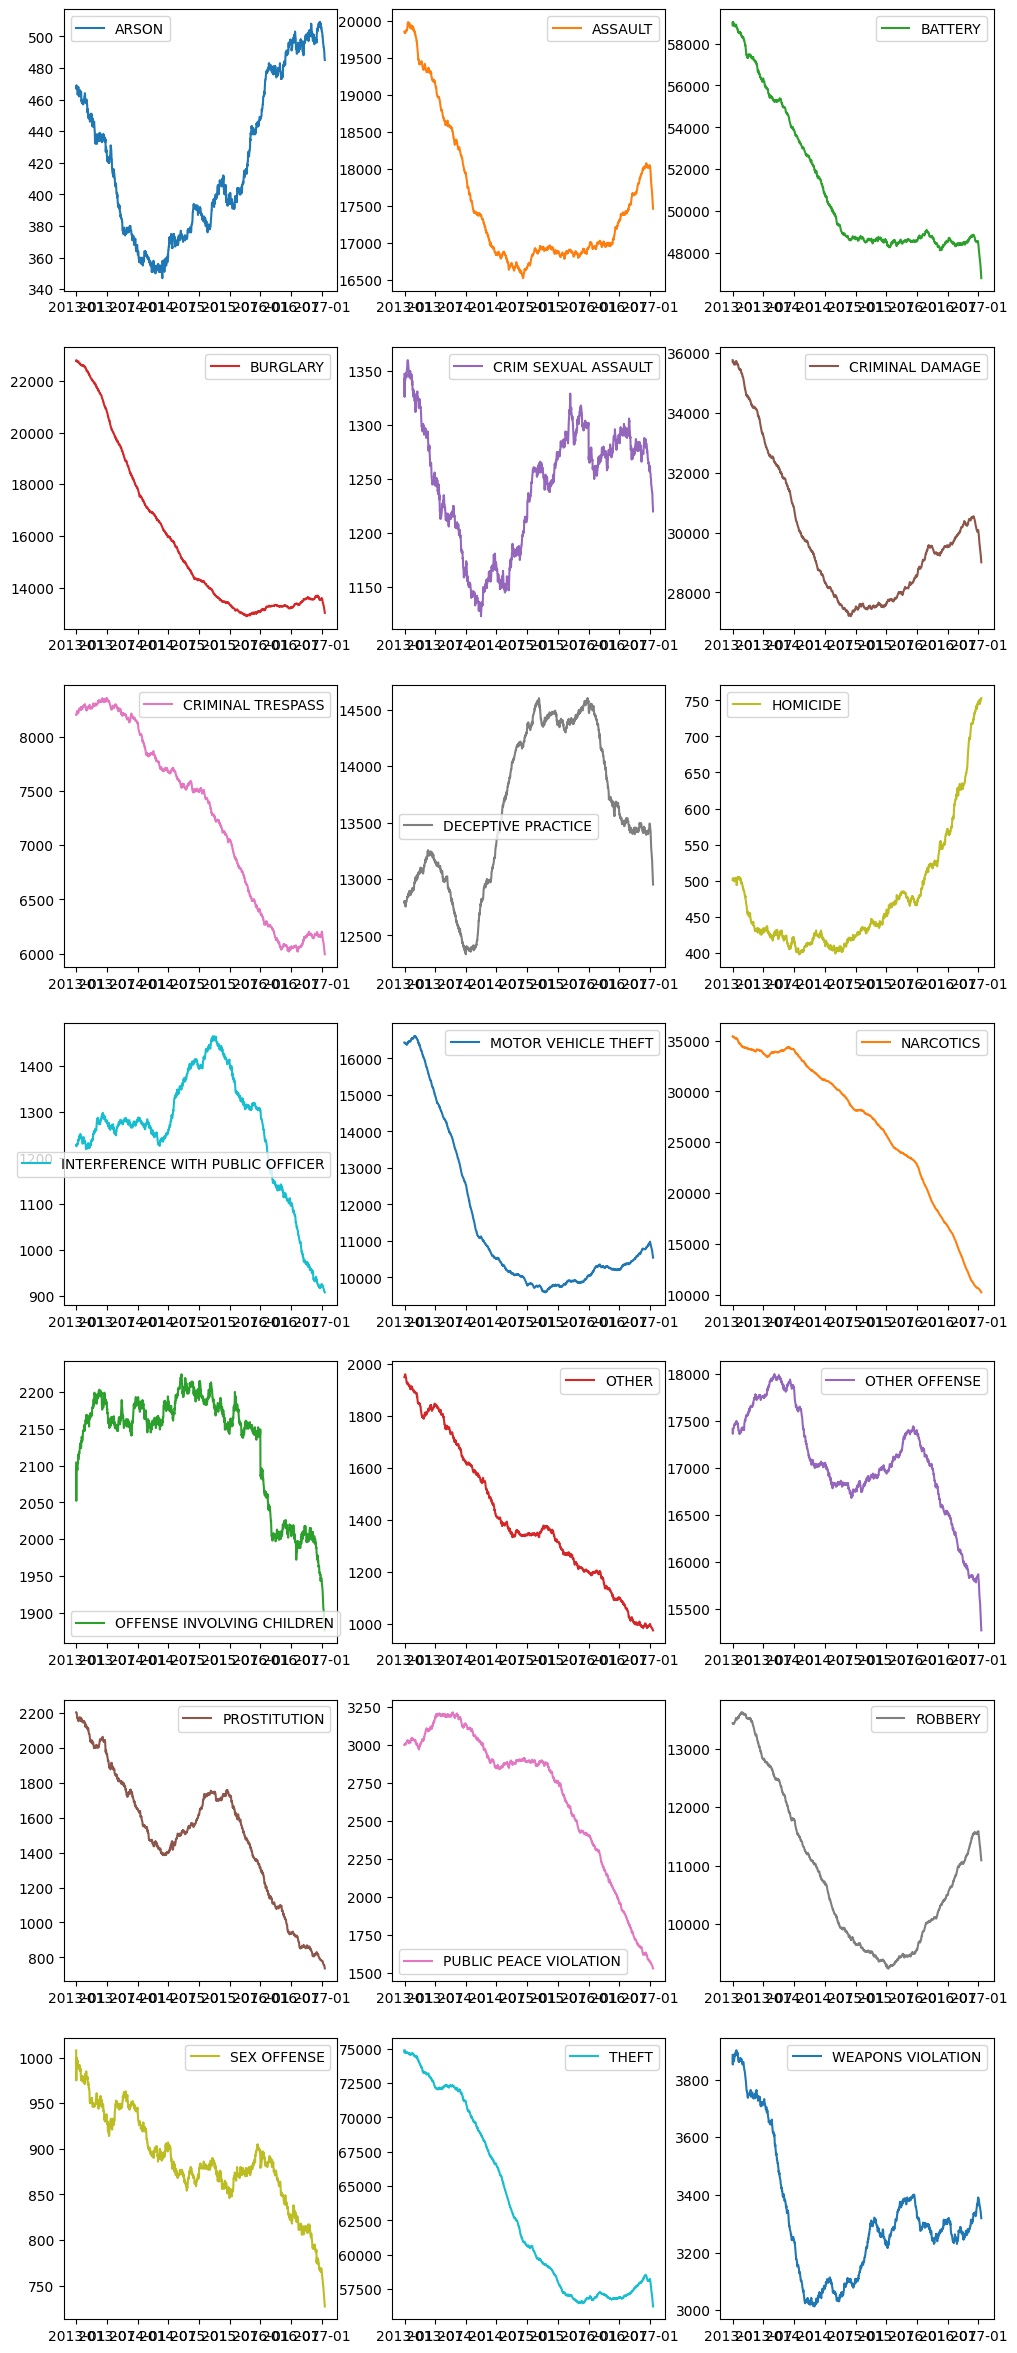

In [ ]:
crímenes_por_fecha = crimes.pivot_table('ID', aggfunc=np.size, columns='Primary Type', index=crimes.index.date, fill_value=0)
crímenes_por_fecha.index = pd.DatetimeIndex(crímenes_por_fecha.index)
plo = crímenes_por_fecha.rolling(365).sum().plot(figsize=(12, 30), subplots=True, layout=(-1, 3), sharex=False, sharey=False)

## Visión general de los registros de crímenes (Tiempo, Ubicacion y Tipo)

#### Crimenes mas frecuentes

<ipython-input-19-c8fe6d6821ba>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  crimes.groupby([crimes['Primary Type']]).size().sort_values(ascending=True).plot(kind='barh')


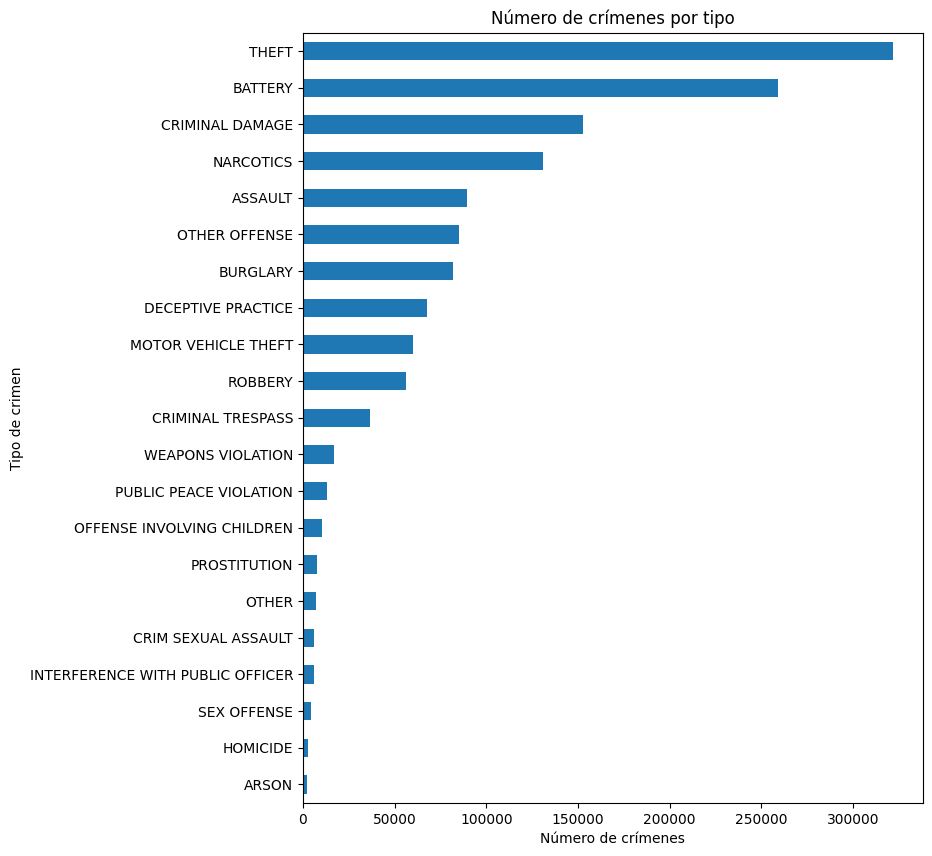

In [ ]:
plt.figure(figsize=(8,10))
crimes.groupby([crimes['Primary Type']]).size().sort_values(ascending=True).plot(kind='barh')
plt.title('Número de crímenes por tipo')
plt.ylabel('Tipo de crimen')
plt.xlabel('Número de crímenes')
plt.show()

<ipython-input-20-e00eca7bf075>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  crimes.groupby([crimes['Location Description']]).size().sort_values(ascending=True).plot(kind='barh')


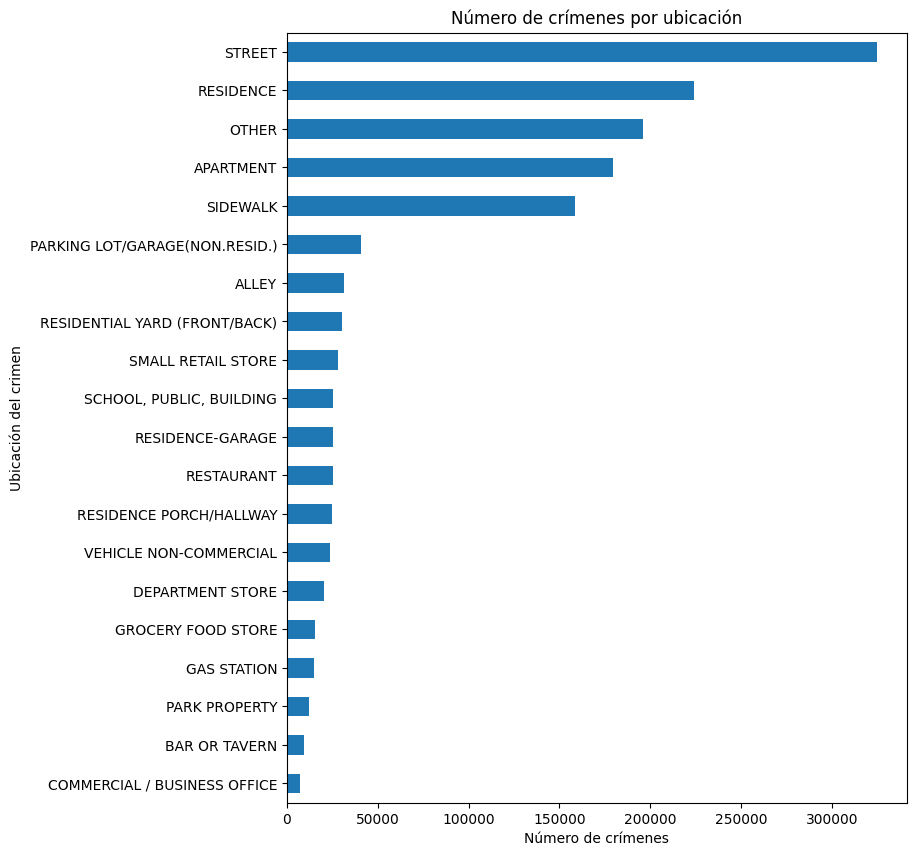

In [ ]:
plt.figure(figsize=(8,10))
crimes.groupby([crimes['Location Description']]).size().sort_values(ascending=True).plot(kind='barh')
plt.title('Número de crímenes por ubicación')
plt.ylabel('Ubicación del crimen')
plt.xlabel('Número de crímenes')
plt.show()

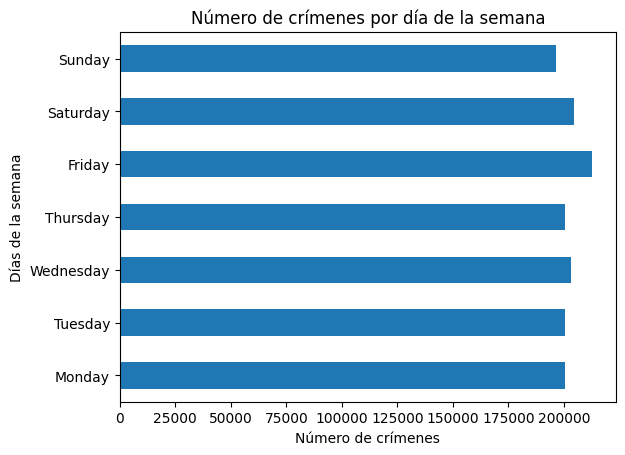

In [ ]:
# Días de la semana
days = ['Monday','Tuesday','Wednesday',  'Thursday', 'Friday', 'Saturday', 'Sunday']
# Contar los crímenes por día de la semana y generar un gráfico de barras horizontales
crimes.groupby([crimes.index.dayofweek]).size().plot(kind='barh')

# Configuración de etiquetas y título
plt.ylabel('Días de la semana')
plt.yticks(np.arange(7), days)
plt.xlabel('Número de crímenes')
plt.title('Número de crímenes por día de la semana')

# Mostrar el gráfico
plt.show()

## Análisis Temporal basado en tipo y localización

In [ ]:
hour_by_location = crimes.pivot_table(values='ID', index='Location Description', columns=crimes.index.hour, aggfunc=np.size).fillna(0)
hour_by_type     = crimes.pivot_table(values='ID', index='Primary Type', columns=crimes.index.hour, aggfunc=np.size).fillna(0)
hour_by_week     = crimes.pivot_table(values='ID', index=crimes.index.hour, columns=crimes.index.day_name(), aggfunc=np.size).fillna(0)
hour_by_week     = hour_by_week[days].T  # solo reordenar las columnas según el orden de los días
dayofweek_by_location = crimes.pivot_table(values='ID', index='Location Description', columns=crimes.index.dayofweek, aggfunc=np.size).fillna(0)
dayofweek_by_type = crimes.pivot_table(values='ID', index='Primary Type', columns=crimes.index.dayofweek, aggfunc=np.size).fillna(0)
location_by_type  = crimes.pivot_table(values='ID', index='Location Description', columns='Primary Type', aggfunc=np.size).fillna(0)

<ipython-input-22-86b4200536e0>:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  hour_by_location = crimes.pivot_table(values='ID', index='Location Description', columns=crimes.index.hour, aggfunc=np.size).fillna(0)
<ipython-input-22-86b4200536e0>:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  hour_by_type     = crimes.pivot_table(values='ID', index='Primary Type', columns=crimes.index.hour, aggfunc=np.size).fillna(0)
<ipython-input-22-86b4200536e0>:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  day

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def scale_df(df, axis=0):

    return (df - df.mean(axis=axis)) / df.std(axis=axis)

def plot_hmap(df, ix=None, cmap='bwr'):

    if ix is None:
        ix = np.arange(df.shape[0])
    plt.imshow(df.iloc[ix, :], cmap=cmap)
    plt.colorbar(fraction=0.03)
    plt.yticks(np.arange(df.shape[0]), df.index[ix])
    plt.xticks(np.arange(df.shape[1]))
    plt.grid(False)
    plt.show()

def scale_and_plot(df, ix=None, order_by='sum'):

    # Scalar Dataframe
    df_marginal_scaled = scale_df(df.T).T

    # Determinar orden de filas
    if ix is None:
        if order_by == 'sum':
            ix = df_marginal_scaled.sum(axis=1).argsort()  #Ordena filas por total de valores.
        elif order_by == 'random':
            ix = np.random.permutation(df_marginal_scaled.index)  #Orden randomico
        else:
            raise ValueError("Unsupported 'order_by' value. Use 'sum' or 'random'.")

    #
    cap = np.min([np.max(df_marginal_scaled.values), np.abs(np.min(df_marginal_scaled.values))])
    df_marginal_scaled = np.clip(df_marginal_scaled, -1 * cap, cap)

    # Plot the heatmap
    plot_hmap(df_marginal_scaled, ix=ix)

def normalize(df):
    '''
    A function to normalize DataFrame values to the range [0, 1]
    '''
    result = df.copy()
    for feature_name in df.columns:
        max_value = df[feature_name].max()
        min_value = df[feature_name].min()
        result[feature_name] = (df[feature_name] - min_value) / (max_value - min_value)
    return result


#### Horas x tipo de crimen

In [ ]:
plt.figure(figsize=(15,12))
scale_and_plot(hour_by_type)

#### Hora por localizacion

In [ ]:
plt.figure(figsize=(15,7))
scale_and_plot(hour_by_location)

#### Hora por semana

In [ ]:
plt.figure(figsize=(12,4))
scale_and_plot(hour_by_week, ix=np.arange(7))

#### Dia de la semana x tipo de crimen

In [ ]:
plt.figure(figsize=(17,17))
scale_and_plot(dayofweek_by_type)

#### Dia de la semana x localizacion

In [ ]:
plt.figure(figsize=(15,12))
scale_and_plot(dayofweek_by_location)

### ¿Dónde es más probable que ocurra un tipo de crimen determinado?

In [ ]:
from sklearn.preprocessing import normalize

# Normalizar los datos
df = normalize(location_by_type)

# Ordenar filas por la suma de sus valores
ix = np.argsort(np.sum(df, axis=1))

# Graficar heatmap
plt.figure(figsize=(17, 13))
plt.imshow(df[ix, :], cmap='Reds')  # Ordenar las filas por el índice calculado
plt.colorbar(fraction=0.03)
plt.xticks(np.arange(df.shape[1]), location_by_type.columns, rotation='vertical')  # Ajustar columnas
plt.yticks(np.arange(df.shape[0]), location_by_type.index[ix])  # Ajustar filas según el índice ordenado
plt.title('Frecuencia normalizada de ubicaciones para cada crimen')
plt.grid(False)
plt.show()


Este fragmento de código tiene como objetivo limpiar y filtrar los datos de latitud y longitud en el DataFrame crimes.

Primero, establece en 0.0 los valores de Longitude que son menores que -88.0 o mayores que -87.5, y los valores de Latitude que son menores que 41.60 o mayores que 42.05. Esto se hace para filtrar las coordenadas que caen fuera del rango especifico de Chicago. Luego, reemplaza estos valores 0.0 con NaN para marcar que esos datos no son válidos. Finalmente, elimina todas las filas con coordenadas geográficas fuera del rango especificado.

Este proceso ayuda a limpiar los datos, eliminando ubicaciones erróneas o fuera de un área de interés particular

In [ ]:
crimes.iloc[(crimes[['Longitude']].values < -88.0).flatten(), crimes.columns=='Longitude'] = 0.0
crimes.iloc[(crimes[['Longitude']].values > -87.5).flatten(), crimes.columns=='Longitude'] = 0.0
crimes.iloc[(crimes[['Latitude']].values < 41.60).flatten(),  crimes.columns=='Latitude'] = 0.0
crimes.iloc[(crimes[['Latitude']].values > 42.05).flatten(),  crimes.columns=='Latitude'] = 0.0
crimes.replace({'Latitude': 0.0, 'Longitude': 0.0}, np.nan, inplace=True)
crimes.dropna(inplace=True)
#Elimina los registros que estan fuera de el area de coordenadas donde se ubica Chicago.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

train, crimes_new1 = train_test_split(crimes, test_size=0.1, stratify=crimes['Primary Type'], random_state=42)

# Verificar distribución de los estratos
print("Distribución en conjunto original:")
print(crimes['Primary Type'].value_counts())
print("\nDistribución en muestra:")
print(crimes_new1['Primary Type'].value_counts())


Distribución en conjunto original:
Primary Type
THEFT                               321950
BATTERY                             258928
CRIMINAL DAMAGE                     152810
NARCOTICS                           131172
ASSAULT                              89507
OTHER OFFENSE                        85355
BURGLARY                             81669
DECEPTIVE PRACTICE                   67607
MOTOR VEHICLE THEFT                  59852
ROBBERY                              56090
CRIMINAL TRESPASS                    36428
WEAPONS VIOLATION                    16982
PUBLIC PEACE VIOLATION               13013
OFFENSE INVOLVING CHILDREN           10590
PROSTITUTION                          7567
OTHER                                 7117
CRIM SEXUAL ASSAULT                   6298
INTERFERENCE WITH PUBLIC OFFICER      6136
SEX OFFENSE                           4491
HOMICIDE                              2590
ARSON                                 2175
Name: count, dtype: int64

Distribución en muestr

In [ ]:
crimes_new1.info()

In [ ]:
crimes_new1.shape

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

train, crimes_new1 = train_test_split(crimes, test_size=0.02, stratify=crimes['Primary Type'], random_state=42)

# Verificar distribución de los estratos
print("Distribución en conjunto original:")
print(crimes['Primary Type'].value_counts())
print("\nDistribución en muestra:")
print(crimes_new1['Primary Type'].value_counts())

Distribución en conjunto original:
Primary Type
THEFT                               321950
BATTERY                             258928
CRIMINAL DAMAGE                     152810
NARCOTICS                           131172
ASSAULT                              89507
OTHER OFFENSE                        85355
BURGLARY                             81669
DECEPTIVE PRACTICE                   67607
MOTOR VEHICLE THEFT                  59852
ROBBERY                              56090
CRIMINAL TRESPASS                    36428
WEAPONS VIOLATION                    16982
PUBLIC PEACE VIOLATION               13013
OFFENSE INVOLVING CHILDREN           10590
PROSTITUTION                          7567
OTHER                                 7117
CRIM SEXUAL ASSAULT                   6298
INTERFERENCE WITH PUBLIC OFFICER      6136
SEX OFFENSE                           4491
HOMICIDE                              2590
ARSON                                 2175
Name: count, dtype: int64

Distribución en muestr

In [ ]:
crimes_new1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 28367 entries, 2016-04-05 13:20:00 to 2012-10-14 15:00:00
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ID                    28367 non-null  int64         
 1   Date                  28367 non-null  datetime64[ns]
 2   Block                 28367 non-null  object        
 3   Primary Type          28367 non-null  category      
 4   Description           28367 non-null  category      
 5   Location Description  28367 non-null  category      
 6   Arrest                28367 non-null  bool          
 7   Domestic              28367 non-null  bool          
 8   District              28367 non-null  float64       
 9   X Coordinate          28367 non-null  float64       
 10  Y Coordinate          28367 non-null  float64       
 11  Latitude              28367 non-null  float64       
 12  Longitude             28367 non-null  f

In [ ]:
# Copiar el DataFrame original
dataset = crimes_new1.copy()

# Seleccionar coordenadas y transformarlas en DataFrame
coords = dataset[['Latitude', 'Longitude', 'Primary Type', 'Location Description']]

# Identificar variables categóricas
categorical_features = coords.select_dtypes(include=['object', 'category']).columns

# Codificar variables categóricas (si existen)
if not categorical_features.empty:
    encoder = OneHotEncoder(drop='first', sparse_output=False)
    categorical_encoded = encoder.fit_transform(dataset[categorical_features])
else:
    categorical_encoded = np.empty((coords.shape[0], 0))  # Si no hay categóricas, dejamos vacío

# Escalar variables numéricas
numerical_features = coords.select_dtypes(include=np.number).columns
if not numerical_features.empty:
    scaler = StandardScaler()
    numerical_scaled = scaler.fit_transform(coords[numerical_features])
else:
    numerical_scaled = np.empty((coords.shape[0], 0))  # Si no hay numéricas, dejamos vacío

# Concatenar todas las características
X = np.hstack([numerical_scaled, categorical_encoded])

In [ ]:
# Assuming 'X' is defined as in your provided code (the result of the preprocessing steps).
import pandas as pd
# Ensure X is a DataFrame (if it's a NumPy array, convert it first)
if not isinstance(X, pd.DataFrame):
    X = pd.DataFrame(X)
# Save X to a CSV file.
X.to_csv('X_data.csv', index=False)  # index=False prevents writing row indices to the file


In [ ]:
X.shape

(28367, 41)

In [ ]:
crimes_new1.to_csv('crimes_new1.csv', index=False)  # index=False prevents writing row indices
